In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# 1. Load the Dataset
df = pd.read_csv('car data.csv')
print("--- Initial Data Snapshot ---")
print(df.head())

--- Initial Data Snapshot ---
  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  


In [3]:
# 2. Data Preprocessing & Feature Engineering
# Calculate the age of the car (using 2026 as the current year based on context)
df['Car_Age'] = 2026 - df['Year']

# Drop the 'Year' column as we now have 'Car_Age', and 'Car_Name' as it is a high-cardinality string
df.drop(['Year', 'Car_Name'], axis=1, inplace=True)

# One-Hot Encode categorical variables (Fuel_Type, Selling_type, Transmission)
df = pd.get_dummies(df, drop_first=True)

In [4]:
# 3. Define Features (X) and Target (y)
# 'Selling_Price' is the target variable to predict
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

In [5]:
# 4. Train/Test Split
# Split data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Optional: Scale numerical features (helps some regression models converge better)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# 5. Model Initialization and Training
# Using Random Forest Regressor which handles non-linear relationships well
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [7]:
# 6. Make Predictions
y_pred = model.predict(X_test_scaled)

In [8]:
# 7. Model Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2 Score): {r2:.2f}")


--- Model Evaluation Metrics ---
Mean Absolute Error (MAE): 0.62
Mean Squared Error (MSE): 0.87
R-squared (R2 Score): 0.96


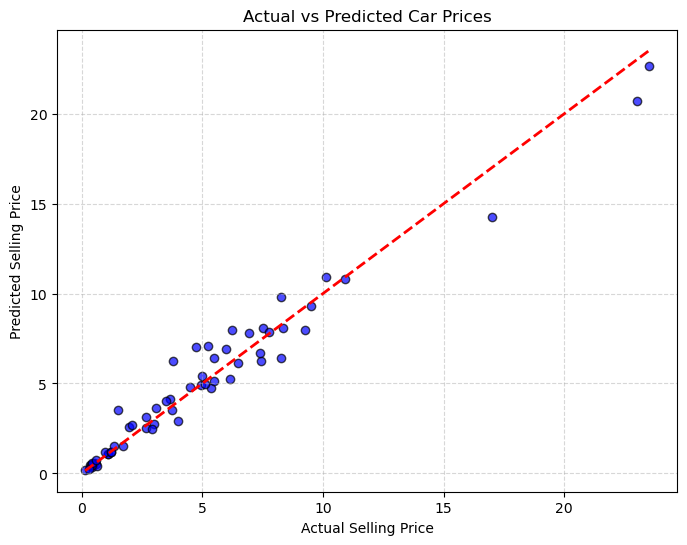

In [9]:
# 8. Visualization using Matplotlib
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='blue', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2)
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predicted Car Prices')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()